# Scenario 3 – Random Forest

**Name:** SaiSanjay R

**Roll No:** 24BAD102

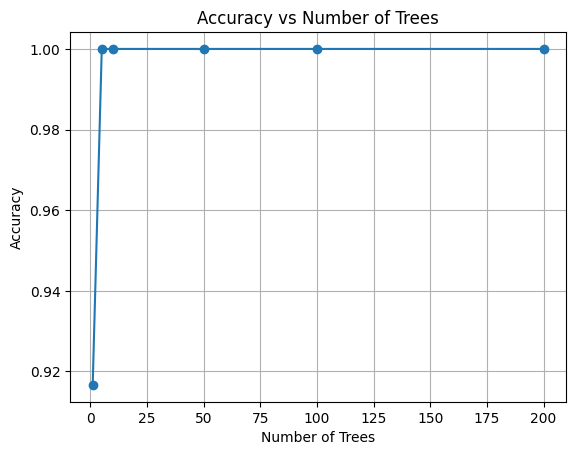

Final Model Accuracy: 1.0


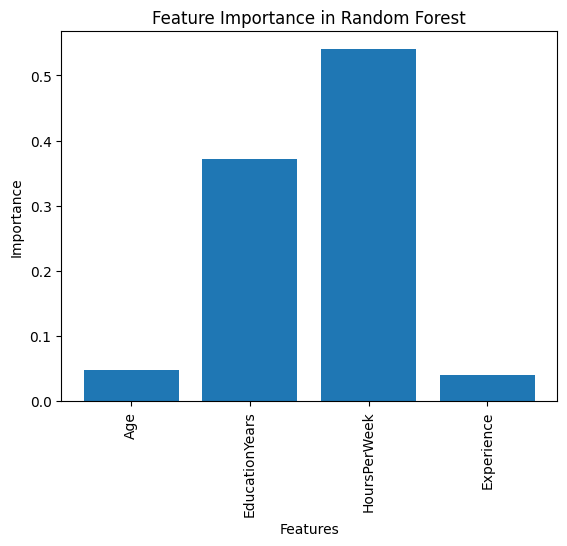

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


df = pd.read_csv('income_random_forest.csv')

X = df.drop('Income', axis=1)
y = df['Income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

trees = [1, 5, 10, 50, 100, 200]
accuracies = []

for t in trees:
    rf = RandomForestClassifier(n_estimators=t, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure()

plt.plot(trees, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")

plt.grid()
plt.show()

rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_train, y_train)

y_pred_final = rf_final.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_final)

print("Final Model Accuracy:", final_accuracy)

importances = rf_final.feature_importances_
features = X.columns

plt.figure()

plt.bar(features, importances)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest")

plt.show()